Lossless compression is probability modeling. Full stop.

If you can predict the next symbol, you can encode it efficiently. The better the prediction, the shorter the code. The theoretical floor is the entropy of the source, and everything above that floor is the gap between your model and the true distribution.

The question is whether a transformer can close that gap without ever being told what distribution the data came from. No parameters, no prior, no generative story. Just a sequence of bits and a model that has to figure out what comes next.

I built a research platform to answer this. Binary sequences only, because binary is where you can compare against closed-form optimal estimators and know exactly how far from the bound you are. The transformer is small, 3 layers, 3 attention heads, roughly 90K parameters. It is trained offline on sequences from some source and then evaluated at test time one bit at a time, same as any classical estimator.

The results are honestly not too bad.


In [1]:
import sys, os
sys.path.insert(0, os.getcwd())
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from toolkit import storage

## The general transformer learns Laplace from data

Start with IID Bernoulli sequences. Flip a biased coin with unknown probability p and generate sequences of length N. The transformer has never seen this p, it was trained on sequences with p drawn uniformly from (0, 1).

At test time the model sees a sequence and predicts P(next bit = 1) at each step. Its baseline is the Laplace estimator, which counts the number of 1s seen so far and computes (k+1)/(t+2). Laplace is near-optimal for IID data and requires zero training.

Across every p we tested (0.1, 0.3, 0.5, 0.7, 0.9) and every sequence length from N=10 to N=499, the transformer tracks Laplace almost exactly. At N=10 the gap is around 0.16 BPS. By N=499 the gap collapses to roughly 0.007 BPS.

This makes sense because there is no temporal structure for the transformer to exploit. The IID source has no memory. What the transformer learns is the inference rule itself: count, add pseudocounts, normalize. It learns to approximate the Bayes-optimal estimator from data alone, without ever being told the prior.


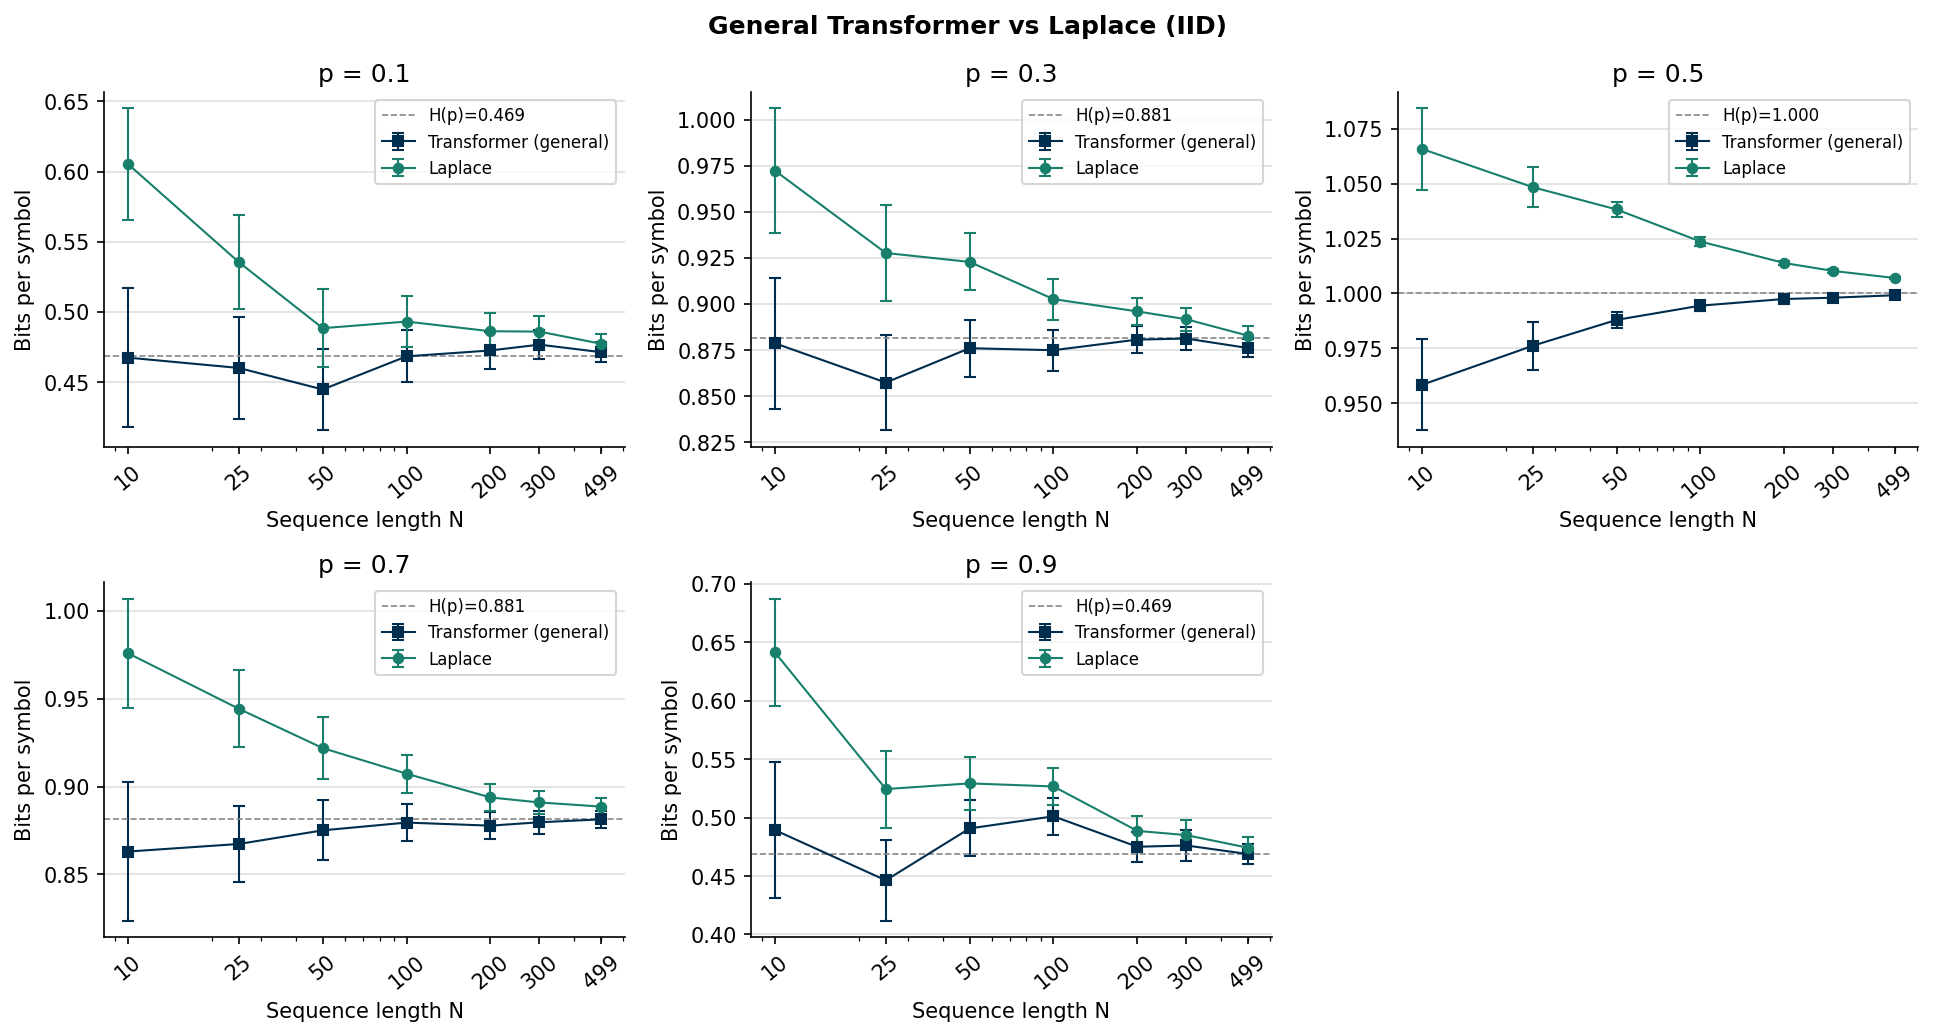


Gap = transformer BPS - Laplace BPS (positive means transformer worse)

p=0.1:
  N=  10: gap=-0.1379
  N=  25: gap=-0.0754
  N=  50: gap=-0.0437
  N= 100: gap=-0.0248
  N= 200: gap=-0.0137
  N= 300: gap=-0.0093
  N= 499: gap=-0.0060

p=0.3:
  N=  10: gap=-0.0936
  N=  25: gap=-0.0703
  N=  50: gap=-0.0468
  N= 100: gap=-0.0277
  N= 200: gap=-0.0153
  N= 300: gap=-0.0105
  N= 499: gap=-0.0067

p=0.5:
  N=  10: gap=-0.1076
  N=  25: gap=-0.0723
  N=  50: gap=-0.0503
  N= 100: gap=-0.0292
  N= 200: gap=-0.0164
  N= 300: gap=-0.0122
  N= 499: gap=-0.0078

p=0.7:
  N=  10: gap=-0.1127
  N=  25: gap=-0.0768
  N=  50: gap=-0.0467
  N= 100: gap=-0.0278
  N= 200: gap=-0.0160
  N= 300: gap=-0.0113
  N= 499: gap=-0.0073

p=0.9:
  N=  10: gap=-0.1521
  N=  25: gap=-0.0781
  N=  50: gap=-0.0385
  N= 100: gap=-0.0256
  N= 200: gap=-0.0136
  N= 300: gap=-0.0089
  N= 499: gap=-0.0054



In [2]:
envelope = storage.load(storage.experiment_path('exp1_iid_general'))
sweep_results = envelope.results

C_TRANSFORMER = '#002d4d'
C_LAPLACE     = '#177F6B'
C_ENTROPY     = '#888888'

fig, axes = plt.subplots(2, 3, figsize=(13, 7), dpi=150)
axes = axes.flatten()

for idx, sr in enumerate(sweep_results):
    ax = axes[idx]
    ns = sr.n_values
    for name, color, marker, label in [
        ('transformer', C_TRANSFORMER, 's', 'Transformer (general)'),
        ('laplace',     C_LAPLACE,     'o', 'Laplace'),
    ]:
        means = [sr.results[name][n]['mean'] for n in ns]
        cis   = [sr.results[name][n]['ci']   for n in ns]
        ax.errorbar(ns, means, yerr=cis, fmt=f'{marker}-', capsize=3,
                    color=color, lw=1.0, ms=4.5, label=label)
    if sr.entropy:
        ent = list(sr.entropy.values())[0]
        ax.axhline(ent, color=C_ENTROPY, ls='--', lw=0.8, label=f'H(p)={ent:.3f}')
    ax.set_xscale('log')
    ax.set_xticks(ns)
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(axis='x', rotation=40)
    ax.set_title(f'p = {sr.param_value}', pad=5)
    ax.set_xlabel('Sequence length N')
    ax.set_ylabel('Bits per symbol')
    ax.grid(True, axis='y', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8)

for ax in axes[len(sweep_results):]:
    ax.set_visible(False)

fig.suptitle('General Transformer vs Laplace (IID)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nGap = transformer BPS - Laplace BPS (positive means transformer worse)\n')
for sr in sweep_results:
    print(f'p={sr.param_value}:')
    for n in sr.n_values:
        gap = sr.results['transformer'][n]['mean'] - sr.results['laplace'][n]['mean']
        print(f'  N={n:4d}: gap={gap:+.4f}')
    print()

## Specialized training gives you a prior

The general model does fine, but it starts every test sequence from square one. It has no information about which p is more likely, because it was trained on a uniform distribution over p.

What happens if you train a transformer on sequences from a single p? Now the model has seen 10,000 sequences all drawn from p=0.3. It knows, in its weights, that p is probably around 0.3.

At N=10 this matters a lot. The specialized transformer hits 0.910 BPS while Laplace sits at 0.976. That 0.066 gap is the value of knowing the source distribution in advance. As sequences grow longer the gap shrinks, because the data overwhelms the prior. By N=499 the gap is 0.007.

This is exactly what you would expect from Bayesian inference. The prior dominates when data is scarce. The likelihood dominates when data is abundant. The transformer learned the prior from its training distribution and uses it at test time the same way a Bayesian estimator would.


## Redundancy scales as 1/m

The H\u00f8st-Madsen bound says the redundancy, which is the gap between the model's BPS and the source entropy, should decay roughly as 1/m where m is the number of training sequences. I tested this by training transformers on m = 10, 25, 50, 75, 100, 150, 200, 300, 500, 1000 sequences and measuring BPS at test length N=100.

The data matches the bound. On a log-log plot the redundancy drops cleanly with a slope near -1. The crossover point where the transformer beats Laplace is around m=100 training sequences. At m=50 the transformer redundancy is 0.040 BPS above entropy, at m=100 it is 0.021, at m=1000 it drops to 0.005.

This is not surprising if you believe the bound, but it is satisfying to see a small transformer hit it. The thing has 90K parameters and was trained for 500 iterations per checkpoint. It is not doing anything exotic. It is just learning the counting rule from repeated exposure, and the efficiency of that learning follows the same scaling law as the optimal estimator.


p=0.3, N_eval=100, entropy=0.8813
Laplace redundancy = 0.0220


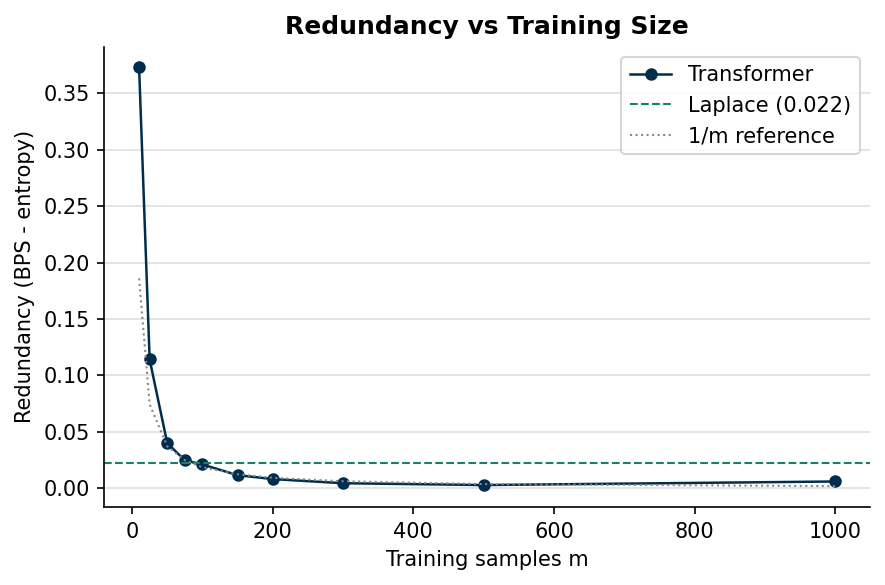


Raw values:
  m=   10: redundancy=0.3731
  m=   25: redundancy=0.1142
  m=   50: redundancy=0.0400
  m=   75: redundancy=0.0248
  m=  100: redundancy=0.0211
  m=  150: redundancy=0.0116
  m=  200: redundancy=0.0081
  m=  300: redundancy=0.0045
  m=  500: redundancy=0.0028
  m= 1000: redundancy=0.0060


In [3]:
import pickle
from toolkit import metrics
with open('notebooks/train_bounds/experiments/benchmark_results.pkl', 'rb') as f:
    r = pickle.load(f)
print(f'p=0.3, N_eval=100, entropy={metrics.entropy_iid(0.3):.4f}')
print(f"Laplace redundancy = {r['laplace']:.4f}")

m_vals_all = sorted(r['transformer'].keys())
m_vals = [m for m in m_vals_all if m <= 1000]
red    = [r['transformer'][m] for m in m_vals]
lap_red = r['laplace']

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.plot(m_vals, red, 'o-', color='#002d4d', lw=1.2, ms=5, label='Transformer')
ax.axhline(lap_red, color='#177F6B', ls='--', lw=1.0, label=f'Laplace ({lap_red:.3f})')

m_arr = np.array(m_vals, dtype=float)
c = red[3] * m_arr[3]
ax.plot(m_arr, c / m_arr, ':', color='#888888', lw=1.0, label='1/m reference')

ax.set_xlabel('Training samples m')
ax.set_ylabel('Redundancy (BPS - entropy)')
ax.set_title('Redundancy vs Training Size', fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('\nRaw values:')
for m, rv in zip(m_vals, red):
    print(f'  m={m:5d}: redundancy={rv:.4f}')

## Markov and FSM: structure is where the money is

IID is the baseline. The interesting part is structured sources.

On the binary symmetric Markov chain the specialized transformer dominates. At p_stay=0.99, where the chain almost never flips, the specialized model hits 0.317 BPS at N=499 while Laplace sits at 0.789 and the general IID transformer at 0.809. CTW eventually catches up (0.317 as well at N=499) but it takes context to get there, at N=10 CTW is stuck at 1.0 because it has not seen enough symbols to fill its context window. The transformer starts strong immediately.

The setup is symmetric: the specialized model was trained on Markov chains with the same p_stay, the IID transformer was trained on IID sequences, and CTW builds a context tree online. The IID transformer does pick up some in-context adaptation on Markov (it tracks the transitions), but the gains are small. What actually beats CTW is knowing the source in advance through specialized training.

On a deterministic 4-state FSM the pattern holds. Specialized transformer leads at every sequence length. N=10: transformer 0.760 BPS, CTW 1.000. N=499: transformer 0.746, CTW 0.798, Laplace 0.810. The ~0.05 BPS gap at long sequences is the transformer's offline knowledge paying off.

On Dirichlet-Markov sources with random transition matrices the specialized transformer beats Laplace and CTW at every alpha tested. The advantage widens as alpha increases (more concentrated priors, less entropy in the transition structure).


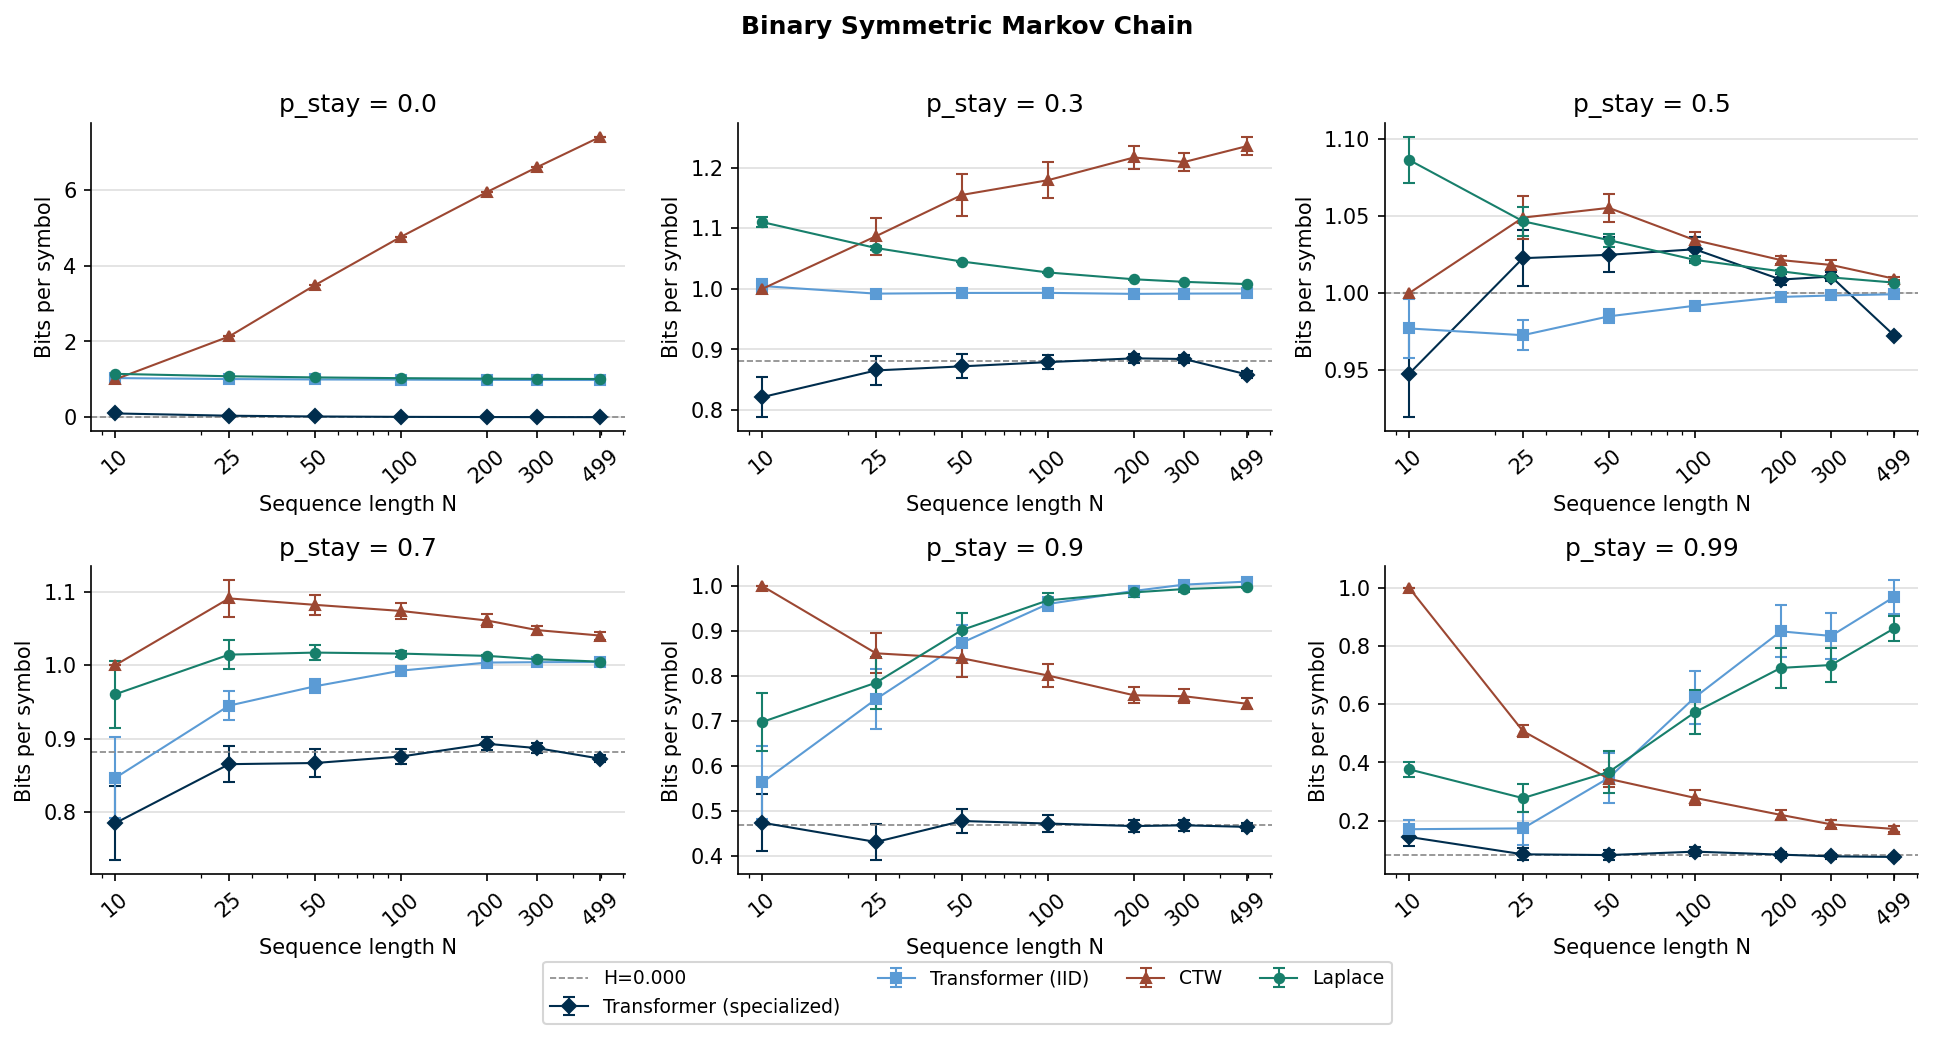


Specialized advantage over CTW (positive = specialized wins)

p_stay=0.0:
  N=  10: +0.9000
  N=  25: +2.0889
  N=  50: +3.4634
  N= 100: +4.7472
  N= 200: +5.9329
  N= 300: +6.5914
  N= 499: +7.3912

p_stay=0.3:
  N=  10: +0.1786
  N=  25: +0.2214
  N=  50: +0.2828
  N= 100: +0.3001
  N= 200: +0.3313
  N= 300: +0.3249
  N= 499: +0.3769

p_stay=0.5:
  N=  10: +0.0524
  N=  25: +0.0264
  N=  50: +0.0305
  N= 100: +0.0060
  N= 200: +0.0127
  N= 300: +0.0075
  N= 499: +0.0369

p_stay=0.7:
  N=  10: +0.2148
  N=  25: +0.2253
  N=  50: +0.2150
  N= 100: +0.1979
  N= 200: +0.1676
  N= 300: +0.1604
  N= 499: +0.1674

p_stay=0.9:
  N=  10: +0.5262
  N=  25: +0.4196
  N=  50: +0.3619
  N= 100: +0.3292
  N= 200: +0.2909
  N= 300: +0.2870
  N= 499: +0.2738

p_stay=0.99:
  N=  10: +0.8561
  N=  25: +0.4240
  N=  50: +0.2621
  N= 100: +0.1849
  N= 200: +0.1367
  N= 300: +0.1101
  N= 499: +0.0961



In [4]:
envelope = storage.load(storage.experiment_path('exp5_markov'))
sweep_results = envelope.results

C_SPECIALIZED = '#002d4d'
C_GENERAL     = '#5B9BD5'
C_LAPLACE     = '#177F6B'
C_CTW         = '#9C4732'
C_ENTROPY     = '#888888'

fig, axes = plt.subplots(2, 3, figsize=(13, 7), dpi=150)
axes = axes.flatten()

for idx, sr in enumerate(sweep_results):
    ax = axes[idx]
    ns = sr.n_values
    for name, color, marker, label in [
        ('specialized', C_SPECIALIZED, 'D', 'Transformer (specialized)'),
        ('general',     C_GENERAL,     's', 'Transformer (IID)'),
        ('ctw',         C_CTW,         '^', 'CTW'),
        ('laplace',     C_LAPLACE,     'o', 'Laplace'),
    ]:
        means = [sr.results[name][n]['mean'] for n in ns]
        cis   = [sr.results[name][n]['ci']   for n in ns]
        ax.errorbar(ns, means, yerr=cis, fmt=f'{marker}-', capsize=3,
                    color=color, lw=1.0, ms=4.5, label=label)
    if sr.entropy:
        ent = list(sr.entropy.values())[0]
        ax.axhline(ent, color=C_ENTROPY, ls='--', lw=0.8, label=f'H={ent:.3f}')
    ax.set_xscale('log')
    ax.set_xticks(ns)
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(axis='x', rotation=40)
    ax.set_title(f'p_stay = {sr.param_value}', pad=5)
    ax.set_xlabel('Sequence length N')
    ax.set_ylabel('Bits per symbol')
    ax.grid(True, axis='y', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, 0.01), fontsize=9)
fig.suptitle('Binary Symmetric Markov Chain', fontsize=12, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.show()

print('\nSpecialized advantage over CTW (positive = specialized wins)\n')
for sr in sweep_results:
    print(f'p_stay={sr.param_value}:')
    for n in sr.n_values:
        adv = sr.results['ctw'][n]['mean'] - sr.results['specialized'][n]['mean']
        print(f'  N={n:4d}: {adv:+.4f}')
    print()

Source: 4-state deterministic
N values: [10, 25, 50, 100, 200, 300, 499]


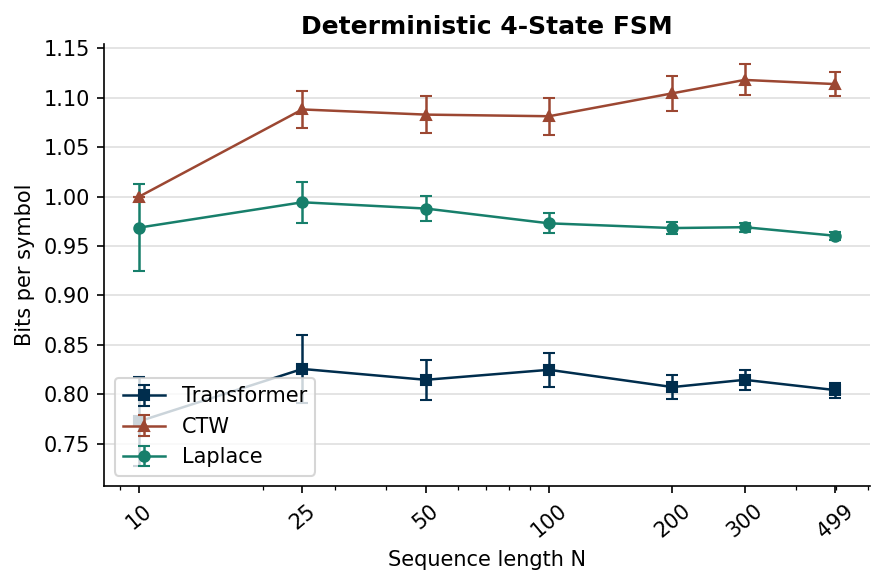


Transformer - CTW BPS (negative = transformer wins)

  N=  10: -0.2274  (transformer wins)
  N=  25: -0.2625  (transformer wins)
  N=  50: -0.2683  (transformer wins)
  N= 100: -0.2565  (transformer wins)
  N= 200: -0.2972  (transformer wins)
  N= 300: -0.3034  (transformer wins)
  N= 499: -0.3096  (transformer wins)


In [5]:
envelope = storage.load(storage.experiment_path('exp7_fsm_benchmark'))
sr = envelope.results
print(f'Source: {sr.param_value}')
print(f'N values: {sr.n_values}')

C_TRANSFORMER = '#002d4d'
C_CTW         = '#9C4732'
C_LAPLACE     = '#177F6B'

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ns = sr.n_values

for name, color, marker, label in [
    ('transformer', C_TRANSFORMER, 's', 'Transformer'),
    ('ctw',         C_CTW,         '^', 'CTW'),
    ('laplace',     C_LAPLACE,     'o', 'Laplace'),
]:
    means = [sr.results[name][n]['mean'] for n in ns]
    cis   = [sr.results[name][n]['ci']   for n in ns]
    ax.errorbar(ns, means, yerr=cis, fmt=f'{marker}-', capsize=3,
                color=color, lw=1.2, ms=5, label=label)

ax.set_xscale('log')
ax.set_xticks(ns)
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax.tick_params(axis='x', rotation=40)
ax.set_xlabel('Sequence length N')
ax.set_ylabel('Bits per symbol')
ax.set_title('Deterministic 4-State FSM', fontweight='bold', pad=5)
ax.legend()
ax.grid(True, axis='y', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('\nTransformer - CTW BPS (negative = transformer wins)\n')
for n in sr.n_values:
    diff = sr.results['transformer'][n]['mean'] - sr.results['ctw'][n]['mean']
    winner = 'transformer' if diff < 0 else 'ctw'
    print(f'  N={n:4d}: {diff:+.4f}  ({winner} wins)')

## Where the counting lives

The cleanest result is from probing the attention heads. The Bayes-optimal estimate for IID data under a Beta(\u03b1, \u03b2) prior is (k+\u03b1)/(t+\u03b1+\u03b2). This is a linear function of two counts: the number of 1s seen (k) and the total symbols seen (t). So you can fit a linear probe to the transformer's attention outputs at each layer and check whether the model has computed this quantity.

It has. For a transformer trained under Beta(5,2), the probe achieves R\u00b2=0.82 at Layer 0. For most models Layer 0 dominates, meaning the counting and prior correction happens in the first attention layer. The raw k/t probe, which just checks whether the model is counting without the prior correction, scores lower at every layer for every model.

What this shows is that the prior correction is in the attention weights, not deferred to the MLP later. The model is doing something structurally Bayesian: count the observations in attention, apply the prior correction in the same operation, output the probability. The R\u00b2 scales with prior concentration too, Beta(0.5,0.5) peaks at 0.43 while Beta(5,2) reaches 0.82, which makes sense because a concentrated prior produces sharper predictions that are easier to read out linearly.

I did not expect the probe to work this cleanly. A 3-layer transformer with 90K parameters learning a closed-form Bayesian estimator from scratch, and you can literally read the estimate off the first layer's attention outputs with a linear regression. That is satisfying in a way that most ML results are not.


Bayes probe R2 ((k+alpha)/(t+alpha+beta)) — layer means:
  Beta(1.0,1.0): L0=0.799  L1=0.563  L2=0.537  max=0.803
  Beta(0.5,0.5): L0=0.189  L1=0.587  L2=0.406  max=0.669
  Beta(5.0,5.0): L0=0.018  L1=0.276  L2=0.362  max=0.368
  Beta(5.0,2.0): L0=0.351  L1=0.826  L2=0.848  max=0.861
  Beta(2.0,5.0): L0=0.353  L1=0.728  L2=0.833  max=0.839

KT probe R2 (k/t) — layer means:
  Beta(1.0,1.0): L0=0.752  L1=0.510  L2=0.479  max=0.759
  Beta(0.5,0.5): L0=0.187  L1=0.559  L2=0.353  max=0.635
  Beta(5.0,5.0): L0=0.035  L1=0.155  L2=0.248  max=0.270
  Beta(5.0,2.0): L0=0.096  L1=0.692  L2=0.737  max=0.740
  Beta(2.0,5.0): L0=0.232  L1=0.628  L2=0.737  max=0.739


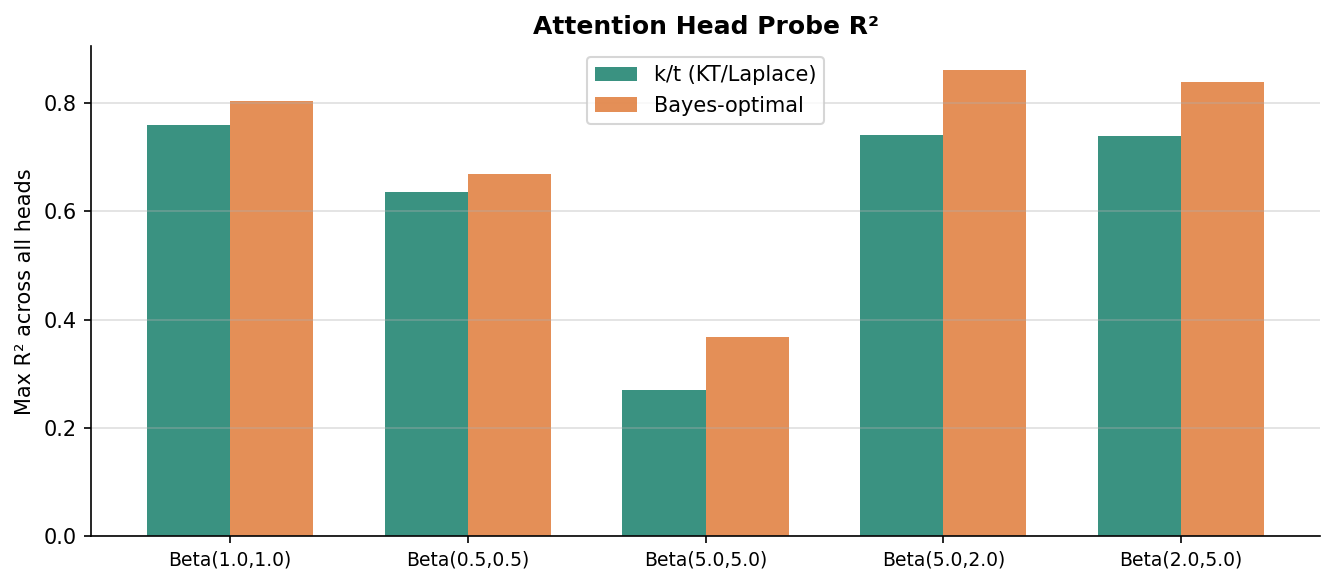

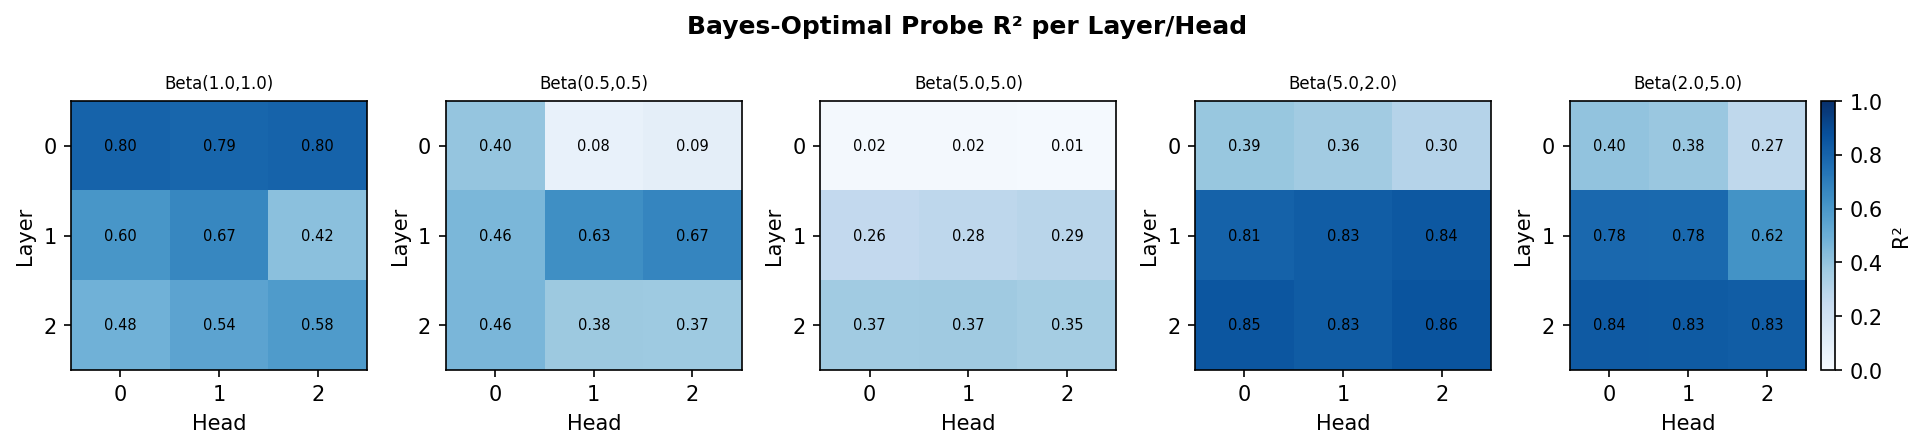

In [6]:
envelope = storage.load(storage.experiment_path('exp8_attention_probe'))
r = envelope.results
priors = r['priors']

print('Bayes probe R2 ((k+alpha)/(t+alpha+beta)) — layer means:')
for prior in priors:
    lm = r[prior]['bay_r2_layer_means']
    print(f'  {prior}: L0={lm[0]:.3f}  L1={lm[1]:.3f}  L2={lm[2]:.3f}  max={r[prior]["max_bay_r2"]:.3f}')

print()
print('KT probe R2 (k/t) — layer means:')
for prior in priors:
    lm = r[prior]['kt_r2_layer_means']
    print(f'  {prior}: L0={lm[0]:.3f}  L1={lm[1]:.3f}  L2={lm[2]:.3f}  max={r[prior]["max_kt_r2"]:.3f}')

C_KT    = '#177F6B'
C_BAYES = '#E07B39'

x = np.arange(len(priors))
width = 0.35

kt_max  = [r[p]['max_kt_r2']  for p in priors]
bay_max = [r[p]['max_bay_r2'] for p in priors]

fig, ax = plt.subplots(figsize=(9, 4), dpi=150)
ax.bar(x - width/2, kt_max,  width, label='k/t (KT/Laplace)', color=C_KT,    alpha=0.85)
ax.bar(x + width/2, bay_max, width, label='Bayes-optimal',    color=C_BAYES, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(priors, fontsize=9)
ax.set_ylabel('Max R\u00b2 across all heads')
ax.set_title('Attention Head Probe R\u00b2', fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, len(priors), figsize=(13, 3), dpi=150)
for ax2, prior in zip(axes2, priors):
    mat = np.array(r[prior]['bay_r2'])
    im = ax2.imshow(mat, vmin=0, vmax=1, cmap='Blues', aspect='auto')
    ax2.set_title(prior, fontsize=8)
    ax2.set_xlabel('Head')
    ax2.set_ylabel('Layer')
    ax2.set_xticks(range(mat.shape[1]))
    ax2.set_yticks(range(mat.shape[0]))
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax2.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=7)
fig2.colorbar(im, ax=axes2[-1], label='R\u00b2')
fig2.suptitle('Bayes-Optimal Probe R\u00b2 per Layer/Head', fontweight='bold')
plt.tight_layout()
plt.show()

## The toolkit: a clean break from notebook sprawl

The original experiments lived in notebooks scattered across the repo. IID experiments in one notebook, Markov in another, training bounds in a third. Three different pkl schemas accumulated through iterative work. Loading an old result meant remembering which notebook format it used.

This is standard research code and it sucked to work with.

The clean version is a toolkit under hard agent constraints. The agent can import only from `toolkit/` and can write only to `experiments/`. Every experiment produces exactly two files: a script that runs and saves results, and an analysis notebook the agent writes from scratch using nbformat. The agent never touches `mingpt/`, `ctw/`, or any original notebook.

A source is just a callable `(n, seed) -> np.ndarray` of 0s and 1s. The five canonical sources are convenience functions. You can write a custom source as an inline lambda and pass it directly to `SequenceDataset`. The estimator interface is the same shape: any callable `(seq) -> np.ndarray` of P(next=1) values works.

`block_size = seq_len - 1` is the single source of truth. This is never set manually, it is derived from the dataset and flows into model training automatically. A model evaluated on sequences longer than its training length falls back to 0.5 padding, which is intentional. Watching estimators converge from their uninformative prior is the whole measurement.

The design decisions are documented in `DESIGN.md` with a why for each one. This is partly for me six months from now and partly for the agents that will write experiments against this toolkit. If a decision looks arbitrary there is a reason, and the reason is written down next to the decision.


## What is missing

The whole system is synthetic binary sequences. No real data, no larger alphabets, no multi-dimensional sources. Generalizing to bytes or text is the obvious next step but it changes the comparison landscape. You lose the closed-form optimal estimators and have to compare against practical compressors instead of information-theoretic bounds.

The attention probe result is the one I want to push further. If a 3-layer transformer can learn a Bayesian estimator in Layer 0 attention, what does a deeper transformer do with more complex sources? Does the counting move up through the layers? Does the model learn to decompose structured sources into independent counting problems?

The platform exists to run those experiments now. The toolkit, the agent constraints, the storage format, the experiment shape are all in place. The question is just which source to throw at it next.
